In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report

pd.set_option("display.max_columns", None)
sns.set(style="whitegrid")

# Example: Load a CSV file from Google Drive
# Replace 'path/to/your/file.csv' with the actual path to your file
# For example: '/content/drive/MyDrive/my_folder/my_data.csv'
try:
    file_path = '/content/drive/MyDrive/189/project/data/humsavar_dbnsfp53_merged_fast.csv' # CHANGE THIS PATH
    df = pd.read_csv(file_path, na_values="?")
    print(f"Successfully loaded data from {file_path}")
    display(df.head())
except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found. Please ensure the path is correct and Google Drive is mounted.")
except Exception as e:
    print(f"An error occurred: {e}")

Successfully loaded data from /content/drive/MyDrive/189/project/data/humsavar_dbnsfp53_merged_fast.csv


/tmp/ipykernel_13000/1202426911.py:17: DtypeWarning: Columns (8) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path, na_values="?")


,Gene,Entry,FTId,AA_change,Category,dbSNP,Disease,Label,chr,pos,ref,alt,rs_dbSNP,SIFT_score,SIFT_pred,Polyphen2_HDIV_score,Polyphen2_HDIV_pred,CADD_raw,CADD_phred,REVEL_score
0,ALPL,P05186,VAR_025914,p.Thr148Ile,LP/P,rs1376937780,Hypophosphatasia (HOPS) [MIM:146300],Pathogenic,1,21563255.0,C,T,rs1376937780,0.41;0.412;0.394;0.41;.,T;T;T;T;.,0.994;.;.;0.994;.,D;.;.;D;.,4.207815,24.60,0.698;0.698;0.698;0.698;.
1,ALPL,P05186,VAR_013980,p.Arg152His,LB/B,rs149344982,Hypophosphatasia (HOPS) [MIM:146300],Benign,1,21563267.0,G,A,rs149344982,0.428;0.377;0.388;0.428;.,T;T;T;T;.,0.072;.;.;0.072;.,B;.;.;B;.,2.326901,18.24,0.262;0.262;0.262;0.262;.
2,ALPL,P05186,VAR_013980,p.Arg152His,LB/B,rs149344982,Hypophosphatasia (HOPS) [MIM:146300],Benign,1,21563267.0,G,C,rs149344982,0.174;0.169;0.174;0.174;.,T;T;T;T;.,0.972;.;.;0.972;.,D;.;.;D;.,3.939432,23.90,0.770;0.770;0.770;0.770;.
3,ALPL,P05186,VAR_025915,p.Gly162Ser,LP/P,rs760029254,Hypophosphatasia (HOPS) [MIM:146300],Pathogenic,1,21564052.0,G,A,rs760029254,0.0;0.0;0.0;0.0;.,D;D;D;D;.,1.0;.;.;1.0;.,D;.;.;D;.,5.444486,32.00,0.993;0.993;0.993;0.993;.
4,ALPL,P05186,VAR_006153,p.Gly162Val,LP/P,rs121918012,Hypophosphatasia (HOPS) [MIM:146300],Pathogenic,1,21564053.0,G,T,rs121918012,0.0;0.0;0.0;0.0;.,D;D;D;D;.,1.0;.;.;1.0;.,D;.;.;D;.,5.493467,32.00,0.981;0.981;0.981;0.981;.


### Double Checking if the dataset loaded in correctly

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119007 entries, 0 to 119006
Data columns (total 20 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Gene                  119007 non-null  object 
 1   Entry                 119007 non-null  object 
 2   FTId                  119007 non-null  object 
 3   AA_change             119007 non-null  object 
 4   Category              119007 non-null  object 
 5   dbSNP                 119007 non-null  object 
 6   Disease               119007 non-null  object 
 7   Label                 119007 non-null  object 
 8   chr                   109451 non-null  object 
 9   pos                   109451 non-null  float64
 10  ref                   109451 non-null  object 
 11  alt                   109451 non-null  object 
 12  rs_dbSNP              109451 non-null  object 
 13  SIFT_score            106264 non-null  object 
 14  SIFT_pred             106264 non-null  object 
 15  

In [6]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Gene,119007,12648,FBN1,643,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Entry,119007,12667,P35555,643,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FTId,119007,71820,VAR_026192,24,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AA_change,119007,49277,p.Ala2Val,25,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Category,119007,2,LB/B,68368,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dbSNP,119007,61782,-,8765,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Disease,119007,4633,-,68117,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Label,119007,2,Benign,68368,NaN,NaN,NaN,NaN,NaN,NaN,NaN
chr,109451.0,26.0,1.0,10808.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
pos,109451.0,NaN,NaN,NaN,73259077.008689,57766336.102843,3316.0,30756011.5,54727298.0,110516045.5,248855917.0


In [7]:
print("Columns:")
for col in df.columns:
    print(col)

Columns:
Gene
Entry
FTId
AA_change
Category
dbSNP
Disease
Label
chr
pos
ref
alt
rs_dbSNP
SIFT_score
SIFT_pred
Polyphen2_HDIV_score
Polyphen2_HDIV_pred
CADD_raw
CADD_phred
REVEL_score


### Labeling Check

In [8]:
df["Label"].value_counts(dropna=False)

,count
Label,
Benign,68368
Pathogenic,50639


In [9]:
df["Category"].value_counts(dropna=False)

,count
Category,
LB/B,68368
LP/P,50639


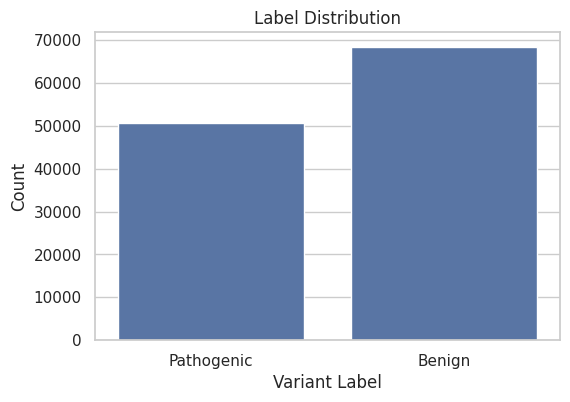

In [10]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Label")
plt.title("Label Distribution")
plt.xlabel("Variant Label")
plt.ylabel("Count")
plt.show()

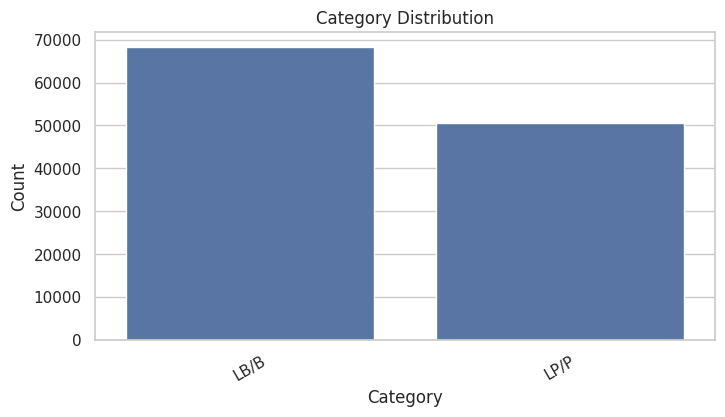

In [11]:
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x="Category", order=df["Category"].value_counts().index)
plt.title("Category Distribution")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.show()

The Label Distribution plot shows that the dataset contains both Pathogenic and Benign missense variants, with benign variants appearing more frequently. There are roughly 68,000 benign variants compared to about 50,000 pathogenic variants. This means the dataset is somewhat imbalanced, but not extremely so. Since both classes are well represented, the dataset is still suitable for comparing how well pathogenicity predictors distinguish harmful variants from benign ones.

The Category Distribution plot shows a similar split using the original dataset categories. The LB/B category, which represents likely benign or benign variants, has the largest count at around 68,000 variants. The LP/P category, representing likely pathogenic or pathogenic variants, has around 50,000 variants. This confirms that the simplified labels align with the original clinical categories: benign variants are more common than pathogenic variants in this dataset.

Overall, these plots show that the dataset has a large number of labeled variants from both classes, making it useful for benchmarking tools like SIFT, PolyPhen-2, CADD, and REVEL. However, because benign variants are more common, later analyses should keep class imbalance in mind when interpreting accuracy, false positives, and false negatives.

### Missing Value Check

In [12]:
missing = df.isna().sum().sort_values(ascending=False)
missing_percent = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    "missing_count": missing,
    "missing_percent": missing_percent
})

missing_df[missing_df["missing_count"] > 0]

,missing_count,missing_percent
SIFT_score,12743,10.71
SIFT_pred,12743,10.71
REVEL_score,12530,10.53
Polyphen2_HDIV_score,12397,10.42
Polyphen2_HDIV_pred,12397,10.42
CADD_raw,9768,8.21
CADD_phred,9768,8.21
rs_dbSNP,9556,8.03
chr,9556,8.03
pos,9556,8.03


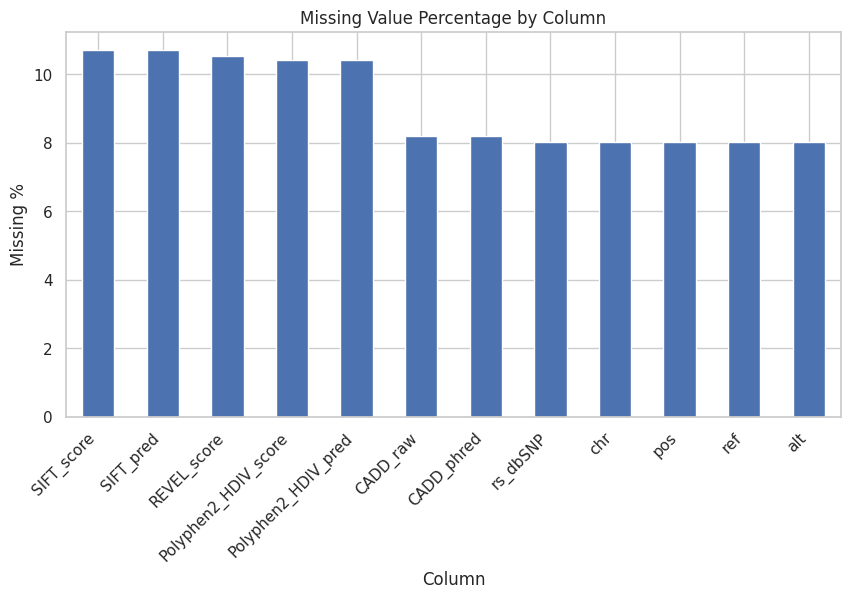

In [13]:
plt.figure(figsize=(10, 5))
missing_df[missing_df["missing_count"] > 0]["missing_percent"].plot(kind="bar")
plt.title("Missing Value Percentage by Column")
plt.ylabel("Missing %")
plt.xlabel("Column")
plt.xticks(rotation=45, ha="right")
plt.show()

The predictor-related columns have the highest missingness. SIFT_score and SIFT_pred are missing for about 10.7% of variants, while REVEL_score, Polyphen2_HDIV_score, and Polyphen2_HDIV_pred are missing for about 10.4–10.5% of variants. This means that roughly one in ten variants does not have scores from these prediction tools.

The CADD_raw and CADD_phred columns have slightly lower missingness, around 8.2%. The genomic location columns, including chr, pos, ref, alt, and rs_dbSNP, are missing for about 8% of variants.

Overall, the missingness is moderate rather than severe. For later analysis, it's better to avoid dropping all rows with any missing value too early, because that could remove a noticeable portion of the dataset.

### Clean numeric predictor column

Some predictor columns may contain semicolon-separated values like "0.12;0.15". This function takes the first usable numeric value.

In [14]:
def clean_numeric_column(series):
    """
    Converts a column to numeric.
    If values contain semicolons, takes the first value.
    """
    return (
        series.astype(str)
        .str.split(";")
        .str[0]
        .replace({"nan": np.nan, ".": np.nan, "": np.nan})
        .astype(float)
    )

In [16]:
numeric_predictors = [
    "SIFT_score",
    "Polyphen2_HDIV_score",
    "CADD_raw",
    "CADD_phred",
    "REVEL_score"
]

for col in numeric_predictors:
    if col in df.columns:
        df[col + "_clean"] = clean_numeric_column(df[col])

df[[col for col in df.columns if col.endswith("_clean")]].head()

,SIFT_score_clean,Polyphen2_HDIV_score_clean,CADD_raw_clean,CADD_phred_clean,REVEL_score_clean
0,0.410,0.994,4.207815,24.60,0.698
1,0.428,0.072,2.326901,18.24,0.262
2,0.174,0.972,3.939432,23.90,0.770
3,0.000,1.000,5.444486,32.00,0.993
4,0.000,1.000,5.493467,32.00,0.981


### Summary of Predictors

In [17]:
clean_predictors = [
    "SIFT_score_clean",
    "Polyphen2_HDIV_score_clean",
    "CADD_raw_clean",
    "CADD_phred_clean",
    "REVEL_score_clean"
]

df[clean_predictors].describe().T

,count,mean,std,min,25%,50%,75%,max
SIFT_score_clean,50569.0,0.185362,0.292676,0.000000,0.001000,0.028000,0.240000,1.000000
Polyphen2_HDIV_score_clean,60876.0,0.564306,0.452960,0.000000,0.010000,0.828000,0.999000,1.000000
CADD_raw_clean,109239.0,3.105293,2.147029,-5.645227,1.405585,3.497264,4.823964,16.276327
CADD_phred_clean,109239.0,19.754023,10.112262,0.001000,13.610000,22.700000,26.900000,69.000000
REVEL_score_clean,51465.0,0.394151,0.346658,0.000000,0.079000,0.251000,0.754000,1.000000


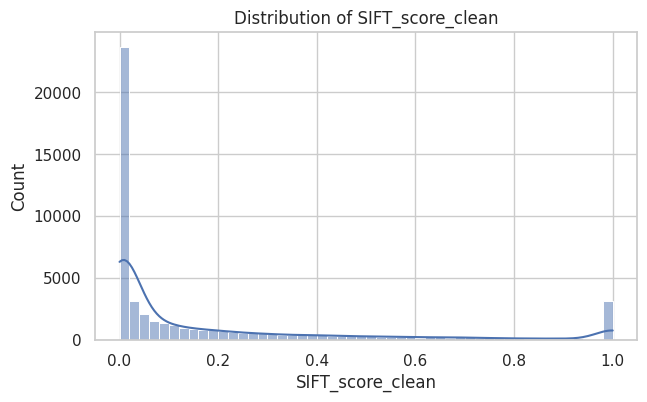

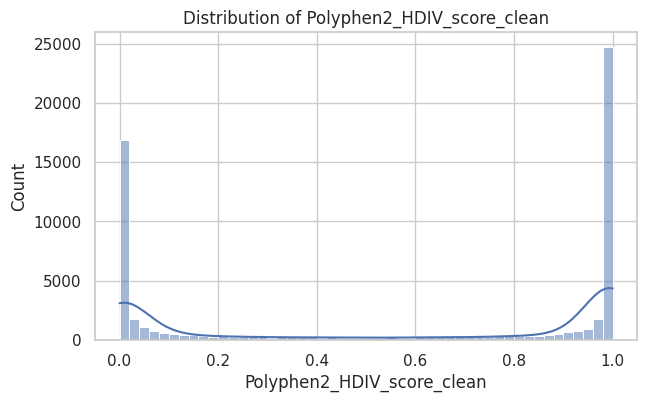

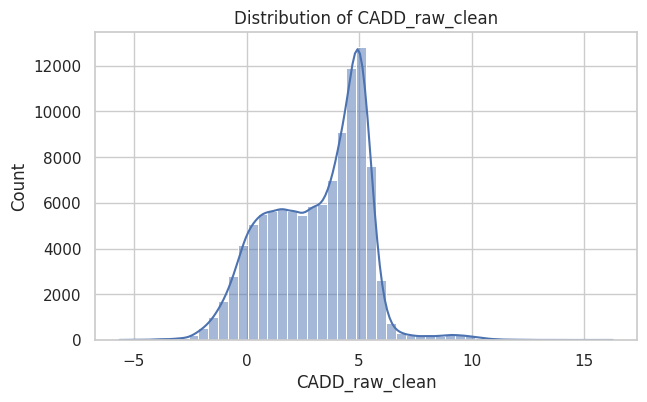

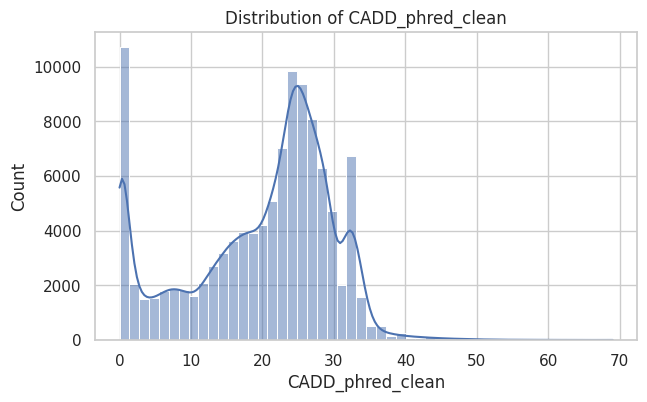

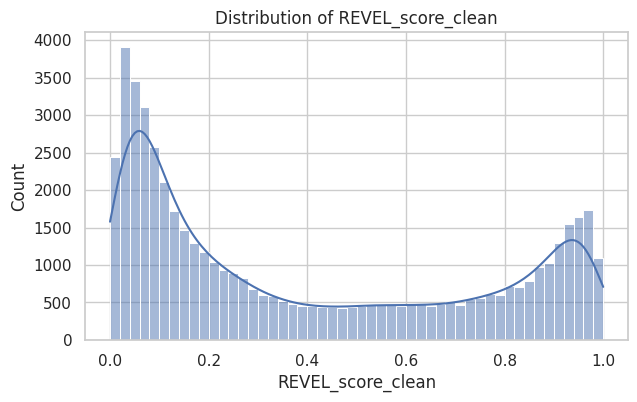

In [18]:
for col in clean_predictors:
    plt.figure(figsize=(7, 4))
    sns.histplot(df[col].dropna(), kde=True, bins=50)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

These plots show how the cleaned pathogenicity predictor scores are distributed across the dataset. Each predictor has a different scoring scale and interpretation, so the shapes of the distributions help show how each tool separates variants into likely benign or likely damaging groups.

The SIFT score distribution is heavily concentrated near 0, with another smaller spike near 1. Since lower SIFT scores indicate more damaging variants, the large peak near 0 suggests that many variants are predicted by SIFT to be damaging. The smaller peak near 1 represents variants predicted to be more tolerated or benign. This sharp concentration near the extremes suggests that SIFT often gives very confident predictions rather than spreading variants evenly across the score range.

The PolyPhen-2 HDIV score distribution is strongly concentrated at both extremes, especially near 0 and 1. Since higher PolyPhen-2 scores indicate more damaging variants, the large spike near 1 suggests many variants are predicted as probably damaging, while the spike near 0 represents variants predicted as benign. This bimodal pattern shows that PolyPhen-2 often makes extreme classifications rather than uncertain middle-range predictions.

The CADD raw score distribution is more continuous and roughly centered between 0 and 6, with a strong peak around 5. Unlike SIFT and PolyPhen-2, CADD raw scores are not limited to a 0–1 range. The distribution suggests that most variants fall into a moderate-to-high deleteriousness range, with fewer variants at very low or very high raw scores.

The CADD phred score distribution has many variants near 0, but also a large concentration between about 15 and 35, with a peak around the mid-20s. Since higher CADD phred scores indicate stronger predicted deleteriousness, this suggests the dataset contains many variants with potentially high functional impact. The spike near 0 may represent variants with low predicted deleteriousness or variants receiving minimal CADD evidence.

The REVEL score distribution is spread across the full 0–1 range but has higher density near both low scores and high scores. Since higher REVEL scores indicate stronger pathogenicity, the low-score peak likely corresponds to variants predicted as benign, while the high-score peak corresponds to variants predicted as pathogenic. Compared with SIFT and PolyPhen-2, REVEL appears more gradual, which may make it useful for analyzing borderline or uncertain variants.

Overall, these plots show that the predictors behave differently. SIFT and PolyPhen-2 produce many extreme scores, while CADD and REVEL show more continuous variation. This is important for the project because predictor failure may occur in variants with borderline scores, disagreement between tools, or cases where one predictor is overly confident while others are more uncertain.

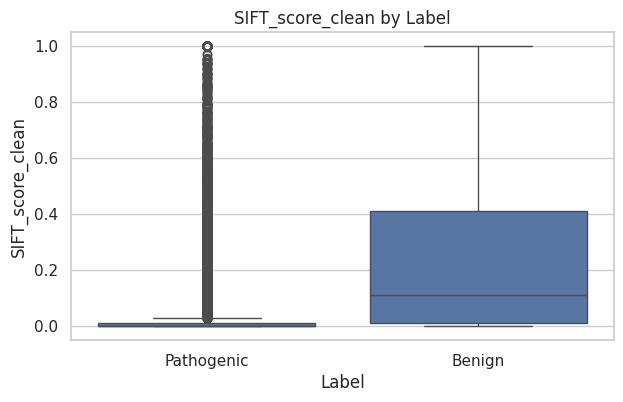

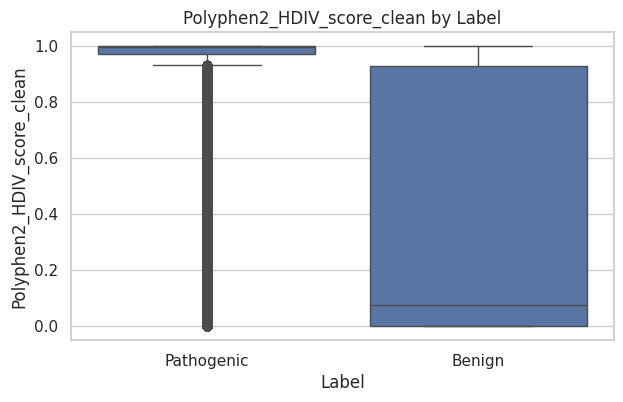

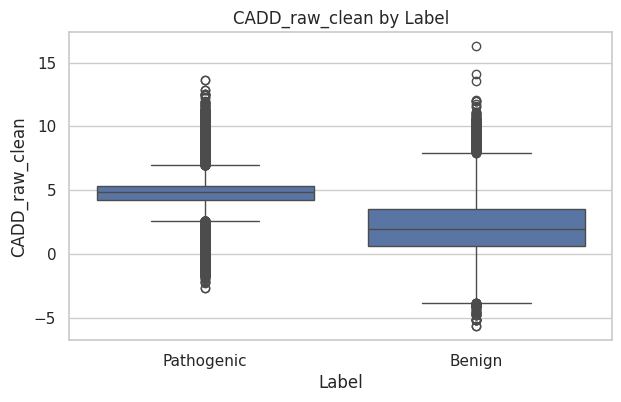

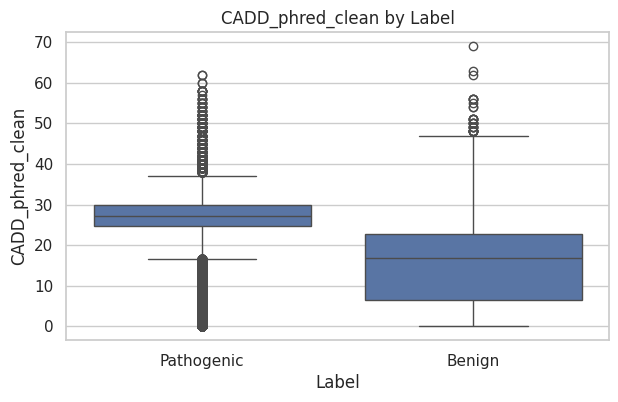

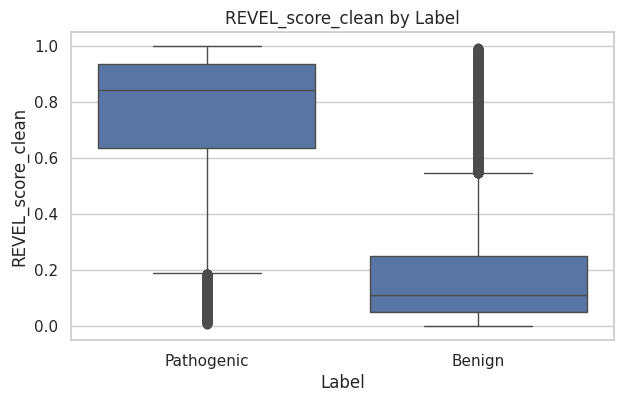

In [19]:
for col in clean_predictors:
    plt.figure(figsize=(7, 4))
    sns.boxplot(data=df, x="Label", y=col)
    plt.title(f"{col} by Label")
    plt.xlabel("Label")
    plt.ylabel(col)
    plt.show()

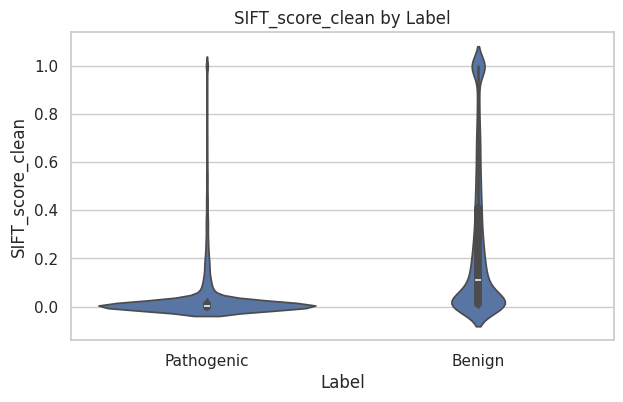

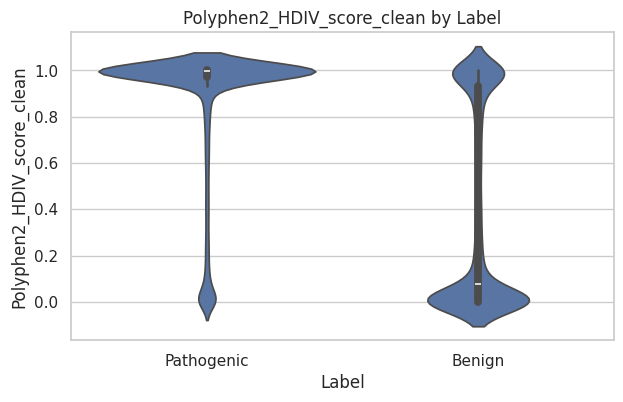

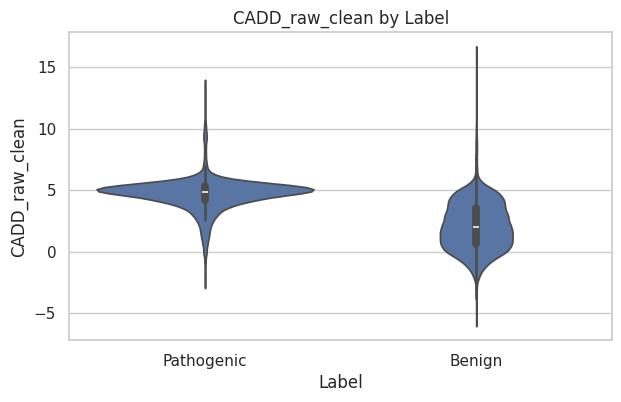

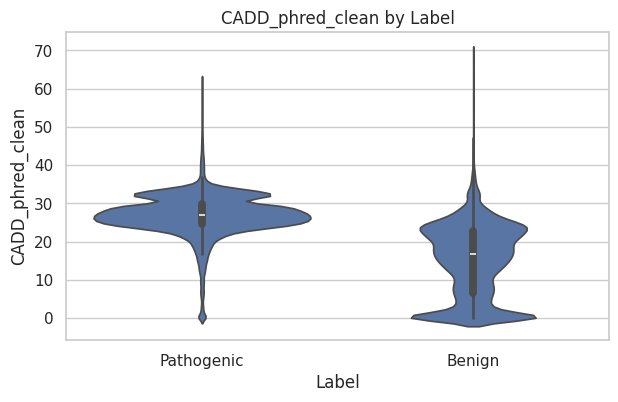

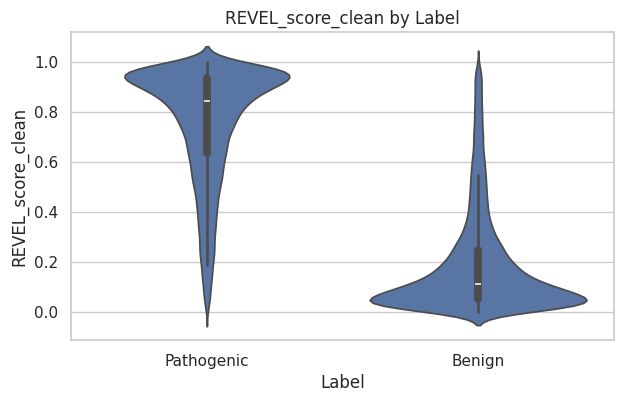

In [20]:
for col in clean_predictors:
    plt.figure(figsize=(7, 4))
    sns.violinplot(data=df, x="Label", y=col)
    plt.title(f"{col} by Label")
    plt.xlabel("Label")
    plt.ylabel(col)
    plt.show()

These violin plots compare each predictor score between Pathogenic and Benign variants. They show whether the predictors assign different score ranges to the two clinical labels.

For SIFT, pathogenic variants are highly concentrated near 0, while benign variants are more spread out and include a large group near 1. Since lower SIFT scores indicate stronger predicted damage, this pattern makes sense: pathogenic variants tend to receive damaging SIFT scores, while benign variants are more likely to receive tolerated scores. However, there is still overlap near low SIFT values, meaning some benign variants are also predicted as damaging. These cases could contribute to false positives.

For PolyPhen-2 HDIV, pathogenic variants are strongly concentrated near 1, while benign variants are concentrated near 0 with some spread toward high values. Since higher PolyPhen-2 scores indicate more damaging variants, this shows strong separation between the two classes. However, some benign variants also receive high PolyPhen-2 scores, which suggests PolyPhen-2 may overpredict damage for certain benign variants.

For CADD raw, pathogenic variants are centered higher, mostly around 4–6, while benign variants are centered lower, mostly around 0–4. This indicates that CADD raw scores generally distinguish pathogenic from benign variants. Still, the distributions overlap, especially around the middle range, showing that CADD alone may not perfectly classify all variants.

For CADD phred, pathogenic variants are mostly concentrated around 25–32, while benign variants are more spread out and often lower, with a large group near 0–25. This again shows that pathogenic variants tend to have higher CADD scores. However, some benign variants reach high CADD phred values, and some pathogenic variants have lower values, indicating possible false positives and false negatives.

Overall, these plots show that all four predictors have useful separation between pathogenic and benign variants, but none are perfect. SIFT and PolyPhen-2 show strong extreme behavior, while CADD scores show more gradual separation. The overlap between the benign and pathogenic distributions is especially important for your project because those overlapping regions likely contain the variants where computational predictors fail.